# Variant Index Attribution vs Frequency

Does the model attribute more to Variant index when that variant was common in training?

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter
from tqdm.auto import tqdm

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

# Load
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device='cpu')

# Find Variant index position
variant_idx_pos = next(i for i, (n, _, _) in enumerate(model.data_set_categories[0]) if 'ariant' in n.lower())
variant_name = model.data_set_categories[0][variant_idx_pos][0]
print(f"Cases: {len(eval_helper.cases)}, Variant feature: '{variant_name}' at pos {variant_idx_pos}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [2]:
# Count variant frequencies per case
def get_variant(case_name):
    case = eval_helper.cases[case_name]
    for _, prefix, _ in eval_helper._iterate_case(case):
        t = prefix[0][variant_idx_pos].squeeze()
        for v in t.tolist():
            if v != 0: return v
        break
    return 0

case_variants = {c: get_variant(c) for c in eval_helper.cases}
variant_counts = Counter(case_variants.values())
print(f"Unique variants: {len(variant_counts)}, Most common: {variant_counts.most_common(5)}")

Unique variants: 57, Most common: [(1, 493), (78, 107), (113, 45), (102, 38), (0, 35)]


In [3]:
# Sample cases (larger sample)
N_SAMPLES = 60
PREFIX_LENGTH = 3

np.random.seed(42)
all_cases = list(case_variants.keys())
sampled = np.random.choice(all_cases, min(N_SAMPLES, len(all_cases)), replace=False)
print(f"Sampled {len(sampled)} cases")

Sampled 60 cases


In [4]:
# Compute attributions
results = []

for case_name in tqdm(sampled, desc="Computing"):
    case = eval_helper.cases[case_name]
    prefix = None
    for pl, p, _ in eval_helper._iterate_case(case):
        if pl >= PREFIX_LENGTH:
            prefix = p
            break
    if prefix is None: continue
    
    try:
        process = ([t.squeeze(0) for t in prefix[0]], [t.squeeze(0) for t in prefix[1]])
        attr_map = tool.compute_attribution_map(
            process=process, prefix_length=PREFIX_LENGTH, target=CONFIG.concept_name,
            target_class='auto', suffix_scope='step', suffix_step=0,
            method='integrated_gradients', n_steps=CONFIG.ig_steps
        )
        
        var_attr = attr_map.attributions[variant_name]
        if hasattr(var_attr, 'detach'): var_attr = var_attr.detach().cpu().numpy()
        var_mag = np.abs(var_attr).sum()
        
        total_mag = sum(np.abs(v.detach().cpu().numpy() if hasattr(v, 'detach') else v).sum() 
                       for v in attr_map.attributions.values())
        
        var_idx = case_variants[case_name]
        results.append({
            'variant_count': variant_counts[var_idx],
            'var_attribution': var_mag,
            'var_ratio': var_mag / total_mag if total_mag > 0 else 0
        })
    except: pass

print(f"Computed: {len(results)}")

Computing:   0%|          | 0/60 [00:00<?, ?it/s]

Computed: 58


In [5]:
# Analysis
freqs = np.array([r['variant_count'] for r in results])
attrs = np.array([r['var_attribution'] for r in results])
ratios = np.array([r['var_ratio'] for r in results])

corr, p_val = stats.pearsonr(freqs, attrs)
corr_log, p_log = stats.pearsonr(np.log1p(freqs), attrs)
corr_ratio, p_ratio = stats.pearsonr(freqs, ratios)

print(f"Correlation (freq vs attribution):     r={corr:.4f}, p={p_val:.4f} {'*' if p_val<0.05 else ''}")
print(f"Correlation (log freq vs attribution): r={corr_log:.4f}, p={p_log:.4f} {'*' if p_log<0.05 else ''}")
print(f"Correlation (freq vs ratio):           r={corr_ratio:.4f}, p={p_ratio:.4f} {'*' if p_ratio<0.05 else ''}")

Correlation (freq vs attribution):     r=-0.7786, p=0.0000 *
Correlation (log freq vs attribution): r=-0.6375, p=0.0000 *
Correlation (freq vs ratio):           r=-0.8759, p=0.0000 *


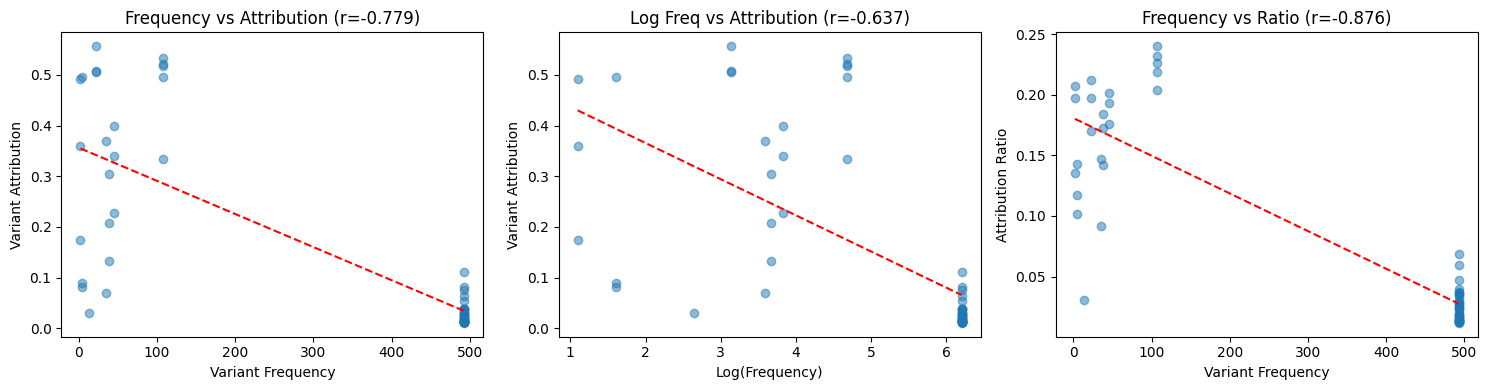


SIGNIFICANT: Model attributes LESS to Variant index for common variants


In [6]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(freqs, attrs, alpha=0.5)
z = np.polyfit(freqs, attrs, 1); axes[0].plot(np.sort(freqs), np.poly1d(z)(np.sort(freqs)), 'r--')
axes[0].set_xlabel('Variant Frequency'); axes[0].set_ylabel('Variant Attribution')
axes[0].set_title(f'Frequency vs Attribution (r={corr:.3f})')

axes[1].scatter(np.log1p(freqs), attrs, alpha=0.5)
z = np.polyfit(np.log1p(freqs), attrs, 1); axes[1].plot(np.sort(np.log1p(freqs)), np.poly1d(z)(np.sort(np.log1p(freqs))), 'r--')
axes[1].set_xlabel('Log(Frequency)'); axes[1].set_ylabel('Variant Attribution')
axes[1].set_title(f'Log Freq vs Attribution (r={corr_log:.3f})')

axes[2].scatter(freqs, ratios, alpha=0.5)
z = np.polyfit(freqs, ratios, 1); axes[2].plot(np.sort(freqs), np.poly1d(z)(np.sort(freqs)), 'r--')
axes[2].set_xlabel('Variant Frequency'); axes[2].set_ylabel('Attribution Ratio')
axes[2].set_title(f'Frequency vs Ratio (r={corr_ratio:.3f})')

plt.tight_layout()
plt.show()

# Conclusion
print("\n" + "="*50)
if p_val < 0.05:
    direction = "MORE" if corr > 0 else "LESS"
    print(f"SIGNIFICANT: Model attributes {direction} to Variant index for common variants")
else:
    print("NOT SIGNIFICANT: No clear relationship between variant frequency and attribution")